In [ ]:
!pip install -q tensorflow_decision_forests seaborn wurlitzer


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

print("TensorFlow:", tf.__version__)
print("TFDF:", tfdf.__version__)


TensorFlow: 2.19.0
TFDF: 1.12.0


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
train.head()


(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train = train.drop("Id", axis=1)
test_ids = test["Id"]
test = test.drop("Id", axis=1)


In [ ]:
def split_fixed(df, test_ratio=0.2, seed=42):
    np.random.seed(seed)
    m = np.random.rand(len(df)) < test_ratio
    return df[~m], df[m]


In [ ]:
y = train["SalePrice"]
X = train.drop("SalePrice", axis=1)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("數值欄位數量 =", len(num_cols))
print("類別欄位數量 =", len(cat_cols))


數值欄位數量 = 36
類別欄位數量 = 43


train shape: (1460, 80)
X shape: (1460, 79) | y shape: (1460,)


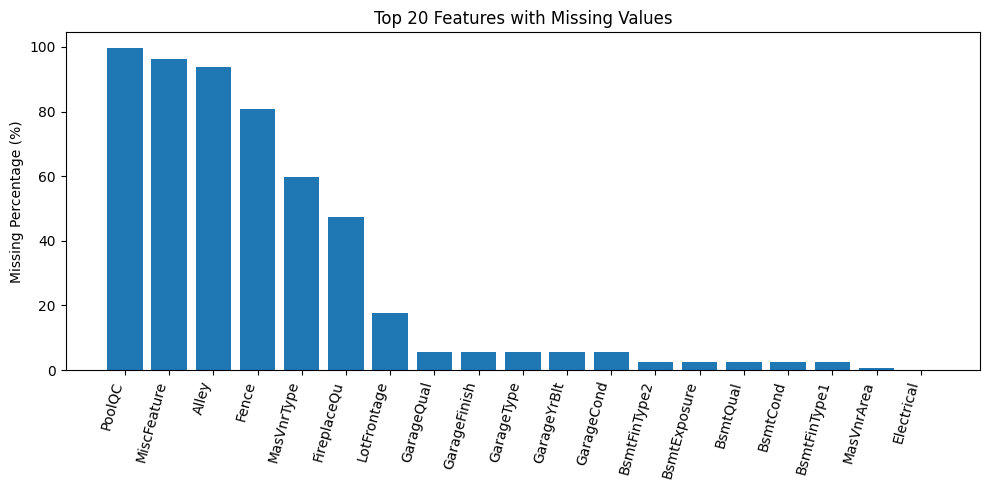

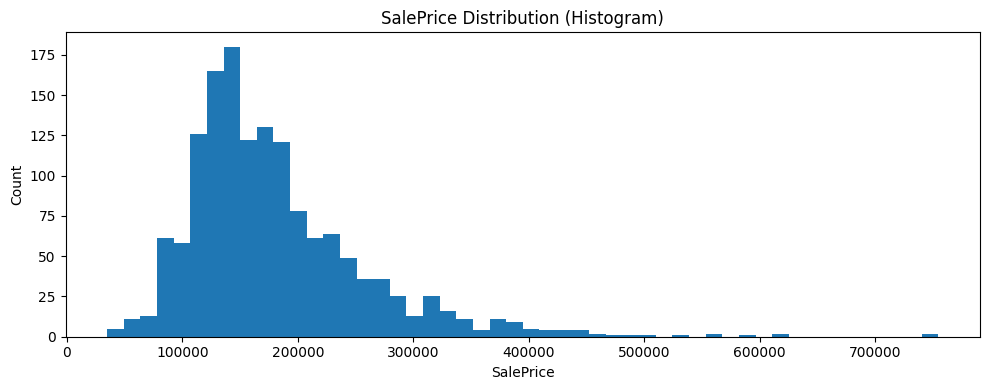

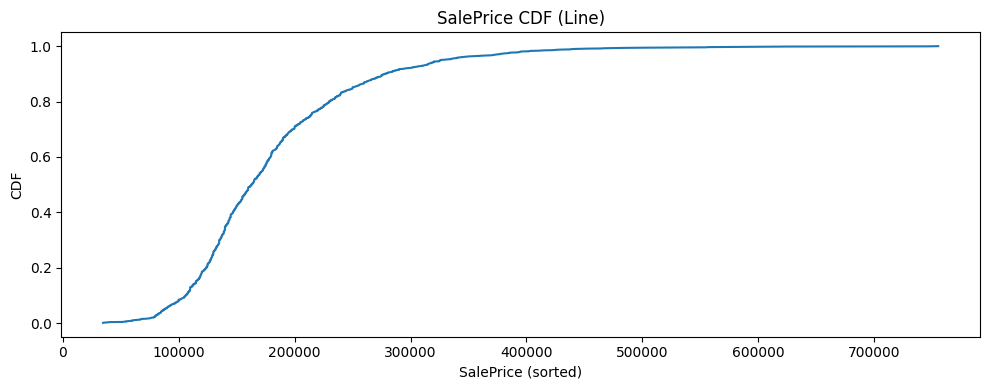

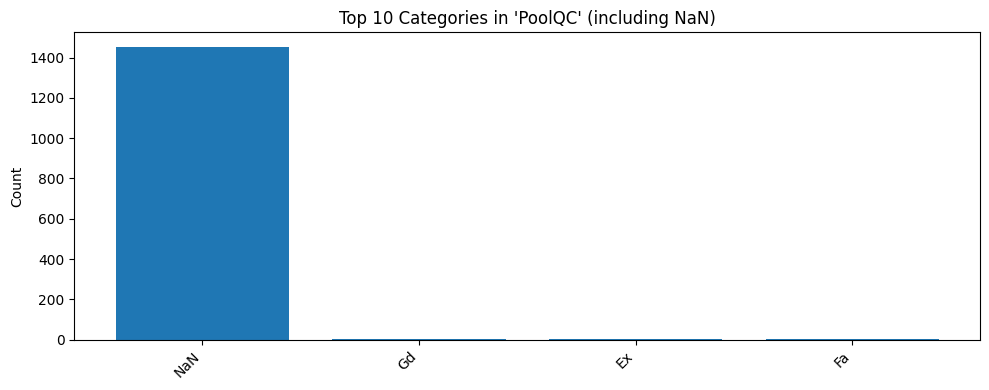

In [ ]:
# ===== EDA / Preprocessing Plots =====
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 0) 基本檢查
print("train shape:", train.shape)
print("X shape:", X.shape, "| y shape:", y.shape)

# 1) 缺失值比例 Top20（長條圖）
miss_pct = (X.isna().mean() * 100).sort_values(ascending=False)
miss_top = miss_pct[miss_pct > 0].head(20)

plt.figure(figsize=(10, 5))
plt.bar(miss_top.index, miss_top.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing Percentage (%)")
plt.title("Top 20 Features with Missing Values")
plt.tight_layout()
plt.show()

# 2) SalePrice 分佈（直方圖 + 累積折線）
y_sorted = np.sort(y.values)
cdf = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

plt.figure(figsize=(10, 4))
plt.hist(y, bins=50)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("SalePrice Distribution (Histogram)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(y_sorted, cdf)
plt.xlabel("SalePrice (sorted)")
plt.ylabel("CDF")
plt.title("SalePrice CDF (Line)")
plt.tight_layout()
plt.show()

# 3) 類別欄位示範：缺失最多的類別欄位 Top10（長條圖）
#   如果 cat_cols 是空的，這段會自動跳過
if len(cat_cols) > 0:
    cat_miss = X[cat_cols].isna().mean().sort_values(ascending=False)
    worst_cat = cat_miss.index[0]  # 缺失率最高的類別欄位
    vc = X[worst_cat].fillna("NaN").value_counts().head(10)

    plt.figure(figsize=(10, 4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(f"Top 10 Categories in '{worst_cat}' (including NaN)")
    plt.tight_layout()
    plt.show()
else:
    print("cat_cols 為空：資料沒有類別欄位可畫。")


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 數值補中位數
num_tf = Pipeline([("imputer", SimpleImputer(strategy="median"))])

# 類別補眾數 + One-hot
cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_tf, num_cols),
    ("cat", cat_tf, cat_cols)
])

rf_sel = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_sel.fit(X, y)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'B...
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# 取得 one-hot 後特徵名
feat_names = rf_sel.named_steps["prep"].get_feature_names_out()
importances = rf_sel.named_steps["model"].feature_importances_

df_imp = pd.DataFrame({
    "feat": feat_names,
    "imp": importances
})

# 還原原始欄位
def revert(name):
    if name.startswith("num__"):
        return name.replace("num__", "")
    if name.startswith("cat__"):
        return name.replace("cat__", "").split("_")[0]
    return name

df_imp["orig"] = df_imp["feat"].apply(revert)

# 合併 one-hot 的原始欄位 importance（取 max）
imp_orig = df_imp.groupby("orig")["imp"].max().sort_values(ascending=False)

imp_orig.head(20)


,imp
orig,
OverallQual,0.578030
GrLivArea,0.109349
TotalBsmtSF,0.038785
2ndFlrSF,0.035449
BsmtFinSF1,0.028894
1stFlrSF,0.022085
GarageCars,0.019613
GarageArea,0.013994
LotArea,0.012677


In [ ]:
k_list = [10, 20, 30, 40, 50, 60]
results = []

for k in k_list:
    topk = imp_orig.head(k).index.tolist()
    df_k = train[topk + ["SalePrice"]]

    # 固定 split
    tr, va = split_fixed(df_k)

    tr_tfdf = tfdf.keras.pd_dataframe_to_tf_dataset(tr, label="SalePrice", task=tfdf.keras.Task.REGRESSION)
    va_tfdf = tfdf.keras.pd_dataframe_to_tf_dataset(va, label="SalePrice", task=tfdf.keras.Task.REGRESSION)

    model = tfdf.keras.RandomForestModel(
        task=tfdf.keras.Task.REGRESSION,
        num_trees=400,
        max_depth=16,
        growing_strategy="BEST_FIRST_GLOBAL",
        random_seed=42
    )
    model.compile(metrics=["mse"])
    model.fit(tr_tfdf)

    eva = model.evaluate(va_tfdf, return_dict=True, verbose=0)
    rmse = eva["mse"] ** 0.5

    print(f"Top{k} RMSE = {rmse:,.2f}")
    results.append((k, rmse))


Use /tmp/tmplo5o61rj as temporary training directory
Reading training dataset...
Training dataset read in 0:00:04.278432. Found 1142 examples.
Training model...
Model trained in 0:00:00.416236
Compiling model...
Model compiled.
Top10 RMSE = 27,876.23
Use /tmp/tmpjkkpdl1y as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.273845. Found 1142 examples.
Training model...
Model trained in 0:00:00.525967
Compiling model...
Model compiled.
Top20 RMSE = 27,697.58
Use /tmp/tmpv0m6p4gz as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.352617. Found 1142 examples.
Training model...
Model trained in 0:00:00.630415
Compiling model...
Model compiled.
Top30 RMSE = 27,167.14
Use /tmp/tmpnsjw61uw as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.448178. Found 1142 examples.
Training model...
Model trained in 0:00:00.707504
Compiling model...
Model compiled.
Top40 RMSE = 26,825

Training dataset read in 0:00:00.508664. Found 1142 examples.
Training model...
Model trained in 0:00:00.819745
Compiling model...


Model compiled.


Top50 RMSE = 27,354.78
Use /tmp/tmpdjjbpnch as temporary training directory
Reading training dataset...


Training dataset read in 0:00:00.905894. Found 1142 examples.
Training model...
Model trained in 0:00:01.214718
Compiling model...


Model compiled.


Top60 RMSE = 27,212.10


In [ ]:
best_k, best_rmse = sorted(results, key=lambda x: x[1])[0]
print("最佳 TopK =", best_k, "RMSE =", best_rmse)


最佳 TopK = 40 RMSE = 26825.604485267428


In [ ]:
best_features = imp_orig.head(best_k).index.tolist()

df_final = train[best_features + ["SalePrice"]]
tr, va = split_fixed(df_final)

tr_tfdf = tfdf.keras.pd_dataframe_to_tf_dataset(tr, label="SalePrice", task=tfdf.keras.Task.REGRESSION)
va_tfdf = tfdf.keras.pd_dataframe_to_tf_dataset(va, label="SalePrice", task=tfdf.keras.Task.REGRESSION)

final_model = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    num_trees=800,
    max_depth=18,
    growing_strategy="BEST_FIRST_GLOBAL",
    random_seed=999
)
final_model.compile(metrics=["mse"])
final_model.fit(tr_tfdf)

eva = final_model.evaluate(va_tfdf, return_dict=True)
rmse_final = eva["mse"] ** 0.5

print("\n🎯 最終 Final Model RMSE =", f"{rmse_final:,.2f}")


Use /tmp/tmpcmn9yvdc as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.434419. Found 1142 examples.
Training model...
Model trained in 0:00:01.432682
Compiling model...
Model compiled.
1/1 [==============================] - 0s 192ms/step - loss: 0.0000e+00 - mse: 717097024.0000

🎯 最終 Final Model RMSE = 26,778.67


In [ ]:
# 🔒 先固定一組相對穩定的 TopK
# 這裡我建議先用 Top 50（你 auto-search 應該有看到表現不錯）

fixed_k = 50
fixed_features = imp_orig.head(fixed_k).index.tolist()

print("使用 fixed TopK =", fixed_k)
print("特徵數量 =", len(fixed_features))
print(fixed_features)


使用 fixed TopK = 50
特徵數量 = 50
['OverallQual', 'GrLivArea', 'TotalBsmtSF', '2ndFlrSF', 'BsmtFinSF1', '1stFlrSF', 'GarageCars', 'GarageArea', 'LotArea', 'YearBuilt', 'FullBath', 'YearRemodAdd', 'LotFrontage', 'TotRmsAbvGrd', 'BsmtUnfSF', 'MasVnrArea', 'WoodDeckSF', 'OpenPorchSF', 'GarageYrBlt', 'OverallCond', 'GarageFinish', 'BsmtQual', 'MoSold', 'Fireplaces', 'GarageType', 'ExterQual', 'KitchenQual', 'BedroomAbvGr', 'MSSubClass', 'CentralAir', 'LotShape', 'YrSold', 'MSZoning', 'BsmtExposure', 'LandContour', 'ScreenPorch', 'HalfBath', 'Exterior2nd', 'BsmtFullBath', 'EnclosedPorch', 'Condition1', 'Exterior1st', 'KitchenAbvGr', 'SaleType', 'Neighborhood', 'LotConfig', 'BsmtFinType1', 'BsmtFinSF2', 'MasVnrType', 'LandSlope']


In [ ]:
# 建 Final dataset（用固定 Top50）
dataset_rf50 = train[fixed_features + ["SalePrice"]].copy()

# 固定 split（跟前面一樣的函式）
train_rf50, valid_rf50 = split_fixed(dataset_rf50, test_ratio=0.2, seed=42)

train_rf50_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_rf50, label="SalePrice", task=tfdf.keras.Task.REGRESSION
)
valid_rf50_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    valid_rf50, label="SalePrice", task=tfdf.keras.Task.REGRESSION
)

# ⚙️ 稍微「收斂一點」的 RF 設定（避免太深過度亂飄）
rf50_model = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    num_trees=600,
    max_depth=16,
    growing_strategy="BEST_FIRST_GLOBAL",
    random_seed=42,
)
rf50_model.compile(metrics=["mse"])

print("開始訓練 RF50 模型 ...")
rf50_model.fit(train_rf50_ds)

eval_rf50 = rf50_model.evaluate(valid_rf50_ds, return_dict=True)
rmse_rf50 = eval_rf50["mse"] ** 0.5

print("\n📊 RF50 Model RMSE =", f"{rmse_rf50:,.2f}")


Use /tmp/tmp5ne30ujs as temporary training directory
開始訓練 RF50 模型 ...
Reading training dataset...
Training dataset read in 0:00:01.202457. Found 1142 examples.
Training model...
Model trained in 0:00:01.206065
Compiling model...
Model compiled.
1/1 [==============================] - 0s 213ms/step - loss: 0.0000e+00 - mse: 744892352.0000

📊 RF50 Model RMSE = 27,292.72


In [ ]:
# ⚡ GradientBoostedTrees 通常比 RF 更適合做回歸

gbt_model = tfdf.keras.GradientBoostedTreesModel(
    task=tfdf.keras.Task.REGRESSION,
    num_trees=600,
    max_depth=8,
    shrinkage=0.05,
    subsample=0.8,
    growing_strategy="BEST_FIRST_GLOBAL",
    random_seed=42,
)

gbt_model.compile(metrics=["mse"])

print("開始訓練 GBT 模型（Top50）...")
gbt_model.fit(train_rf50_ds)

eval_gbt = gbt_model.evaluate(valid_rf50_ds, return_dict=True)
rmse_gbt = eval_gbt["mse"] ** 0.5

print("\n🎯 GBT Model RMSE =", f"{rmse_gbt:,.2f}")


Use /tmp/tmpvhwg9t95 as temporary training directory
開始訓練 GBT 模型（Top50）...
Reading training dataset...
Training dataset read in 0:00:00.517940. Found 1142 examples.
Training model...
Model trained in 0:00:02.943687
Compiling model...
Model compiled.
1/1 [==============================] - 0s 311ms/step - loss: 0.0000e+00 - mse: 526117504.0000

🎯 GBT Model RMSE = 22,937.25


In [ ]:
test_final = test[best_features]
test_tfdf = tfdf.keras.pd_dataframe_to_tf_dataset(test_final, task=tfdf.keras.Task.REGRESSION)

preds = final_model.predict(test_tfdf).squeeze()

sub = pd.DataFrame({"Id": test_ids, "SalePrice": preds})
sub.to_csv("submission.csv", index=False)

sub.head()


2/2 [==============================] - 0s 26ms/step


,Id,SalePrice
0,1461,127074.226562
1,1462,144511.718750
2,1463,174974.250000
3,1464,176789.421875
4,1465,205946.296875
